# DSCI 552 - Homework 2
**Name:** Chengfeng Tang  
**GitHub Username:** tcf2021  
**USC ID:** 5488902262

## 1(a) - Data
I used `Sheet1` of `Folds5x2_pp.xlsx` from the UCI Combined Cycle Power Plant dataset. The workbook labels temperature as AT and electrical output as PE; these correspond to T and EP in the assignment. I retained the original column names and all observations.

I used a significance level of 0.05. Parts (b)-(g) use the full dataset. Parts (h)-(j) use the same random 70% training and 30% test split, with `random_state=42`.

In [1]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="ticks", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 120})
FEATURES = ["AT", "V", "AP", "RH"]
ALPHA = 0.05

def ptext(p):
    return "<1e-300" if p < 1e-300 else f"{p:.3g}"

def coef_table(model):
    return pd.DataFrame({
        "Coefficient": model.params,
        "Std. error": model.bse,
        "t": model.tvalues,
        "p-value": model.pvalues.map(ptext)
    })

data_path = Path("../data/CCPP/Folds5x2_pp.xlsx")
data = pd.read_excel(data_path, sheet_name="Sheet1")
X, y = data[FEATURES], data["PE"]
assert data.shape == (9568, 5)
assert not data.isna().any().any()
print(data.head().to_string(index=False))

   AT     V      AP    RH     PE
14.96 41.76 1024.07 73.17 463.26
25.18 62.96 1020.04 59.08 444.37
 5.11 39.40 1012.16 92.14 488.56
20.86 57.32 1010.24 76.64 446.48
10.82 37.50 1009.23 96.62 473.90


## 1(b)(i) - Rows and columns
There are **9,568 rows and five columns**. Each row is an hourly average observation from the plant operating at full load during 2006-2011. Four columns are predictors: AT (temperature, degrees Celsius), V (exhaust vacuum, cm Hg), AP (ambient pressure, millibar), and RH (relative humidity, percent). PE is the response: net hourly electrical output in MW. There are no missing values.

In [2]:
print("Rows:", len(data), "Columns:", data.shape[1])
print("Missing values:", int(data.isna().sum().sum()))

Rows: 9568 Columns: 5
Missing values: 0


## 1(b)(ii) - Pairwise scatterplots
PE decreases strongly as AT and V increase. PE has weaker positive marginal associations with AP and RH. AT and V are strongly positively related, while AT is negatively related to AP and RH. The bands and curvature in several plots suggest that a single straight line may not capture all of the structure.

       AT      V     AP     RH     PE
AT  1.000  0.844 -0.508 -0.543 -0.948
V   0.844  1.000 -0.414 -0.312 -0.870
AP -0.508 -0.414  1.000  0.100  0.518
RH -0.543 -0.312  0.100  1.000  0.390
PE -0.948 -0.870  0.518  0.390  1.000


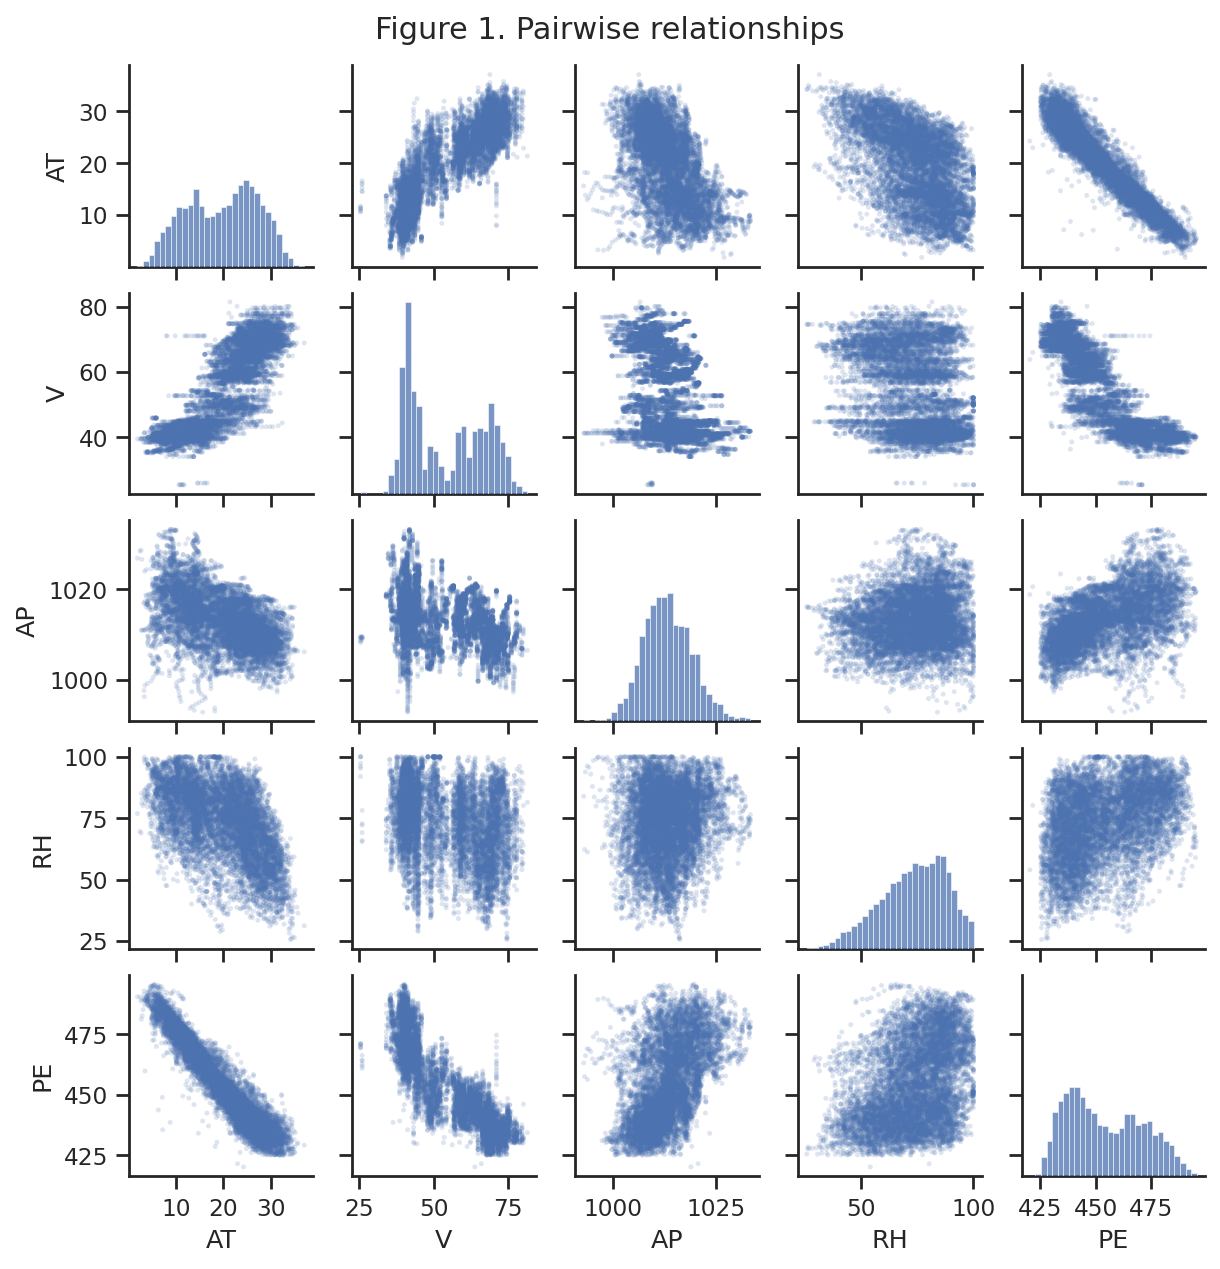

In [3]:
grid = sns.pairplot(
    data, diag_kind="hist",
    plot_kws={"s": 5, "alpha": 0.18, "edgecolor": "none"},
    diag_kws={"bins": 30}, height=1.55
)
grid.figure.suptitle("Figure 1. Pairwise relationships", y=1.02)
plt.show()
print(data.corr().round(3).to_string())

## 1(b)(iii) - Descriptive statistics
The range is the maximum minus the minimum, and the interquartile range is Q3 minus Q1.

In [4]:
q1, q3 = data.quantile(0.25), data.quantile(0.75)
descriptive = pd.DataFrame({
    "Mean": data.mean(), "Median": data.median(),
    "Range": data.max() - data.min(),
    "Q1": q1, "Q3": q3, "IQR": q3 - q1
})
print(descriptive.round(3).to_string())

        Mean    Median  Range        Q1       Q3     IQR
AT    19.651    20.345  35.30    13.510    25.72  12.210
V     54.306    52.080  56.20    41.740    66.54  24.800
AP  1013.259  1012.940  40.41  1009.100  1017.26   8.160
RH    73.309    74.975  74.60    63.328    84.83  21.502
PE   454.365   451.550  75.50   439.750   468.43  28.680


## 1(c) - Simple linear regressions
All four predictors have statistically significant slopes. AT gives the strongest simple linear fit ($R^2=0.8989$), followed by V ($R^2=0.7565$), AP ($R^2=0.2688$), and RH ($R^2=0.1519$). AT and V have negative slopes, whereas AP and RH have positive slopes.

I flagged observations with absolute internally studentized residuals greater than 3. The AT, V, AP, and RH models flag 42, 33, 29, and 2 observations, respectively. These are candidates for inspection, not confirmed data errors. Weak single-predictor models can also produce large residuals because they omit other predictors. I retained all observations rather than removing points solely to improve the fit.

            Intercept    Slope       SE  p-value       R2
Predictor                                                
AT          497.03412 -2.17132  0.00744  <1e-300  0.89895
V           517.80153 -1.16814  0.00678  <1e-300  0.75652
AP        -1055.26099  1.48987  0.02513  <1e-300  0.26877
RH          420.96177  0.45565  0.01101  <1e-300  0.15194

Residual diagnostics:
           Flagged  Largest |r|  Data row (1-based)
Predictor                                          
AT              42        8.471                7665
V               33        4.745                3104
AP              29        4.130                1291
RH               2        3.022                7901


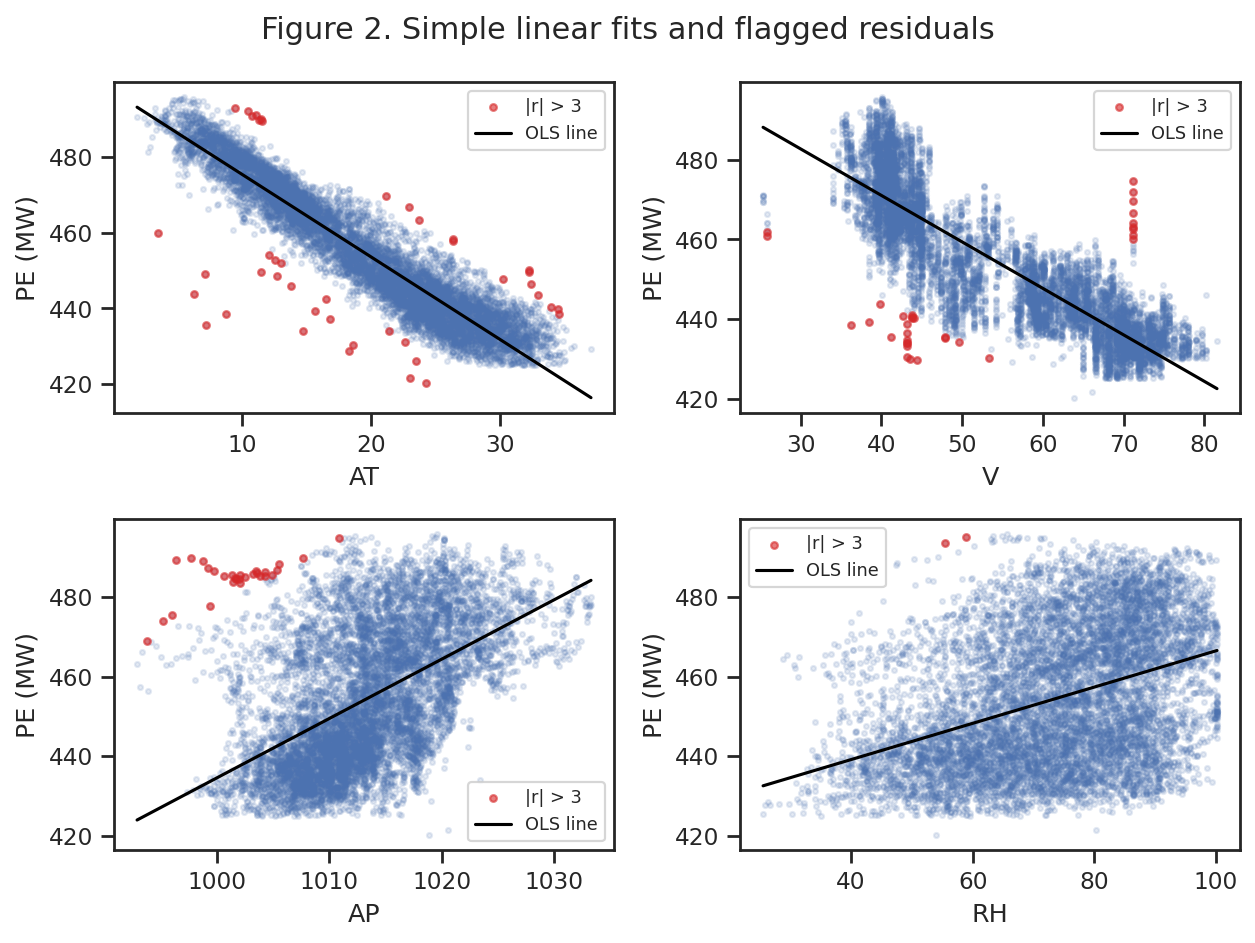

In [5]:
simple = {}
simple_rows = []
outlier_rows = []
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for feature, ax in zip(FEATURES, axes.flat):
    model = sm.OLS(y, sm.add_constant(X[[feature]])).fit()
    simple[feature] = model
    simple_rows.append({
        "Predictor": feature, "Intercept": model.params["const"],
        "Slope": model.params[feature], "SE": model.bse[feature],
        "p-value": ptext(model.pvalues[feature]), "R2": model.rsquared
    })
    residuals = model.get_influence().resid_studentized_internal
    flagged = np.abs(residuals) > 3
    worst = int(np.argmax(np.abs(residuals)))
    outlier_rows.append({
        "Predictor": feature, "Flagged": int(flagged.sum()),
        "Largest |r|": abs(residuals[worst]),
        "Data row (1-based)": worst + 1
    })
    ax.scatter(X[feature], y, s=5, alpha=0.15)
    ax.scatter(X.loc[flagged, feature], y[flagged], s=9,
               color="tab:red", alpha=0.6, label="|r| > 3")
    order = np.argsort(X[feature].to_numpy())
    ax.plot(X[feature].iloc[order], model.fittedvalues.iloc[order],
            color="black", linewidth=1.4, label="OLS line")
    ax.set(xlabel=feature, ylabel="PE (MW)")
    ax.legend(fontsize=8)
fig.suptitle("Figure 2. Simple linear fits and flagged residuals")
fig.tight_layout()
plt.show()
simple_results = pd.DataFrame(simple_rows).set_index("Predictor")
outlier_results = pd.DataFrame(outlier_rows).set_index("Predictor")
print(simple_results.round(5).to_string())
print("\nResidual diagnostics:")
print(outlier_results.round(3).to_string())

## 1(d) - Multiple linear regression
The fitted model is

$$\widehat{PE}=454.6093-1.9775AT-0.2339V+0.0621AP-0.1581RH.$$

All four predictor p-values are below 0.05, so I reject $H_0:\beta_j=0$ for AT, V, AP, and RH. The model explains approximately 92.87% of the variation in PE. Each slope represents the association with PE after holding the other three predictors fixed.

In [6]:
multiple = sm.OLS(y, sm.add_constant(X)).fit()
print(coef_table(multiple).round(5).to_string())
print(f"R2 = {multiple.rsquared:.6f}")
print(f"Adjusted R2 = {multiple.rsquared_adj:.6f}")

       Coefficient  Std. error          t    p-value
const    454.60927     9.74851   46.63371    <1e-300
AT        -1.97751     0.01529 -129.34202    <1e-300
V         -0.23392     0.00728  -32.12211  4.38e-215
AP         0.06208     0.00946    6.56409   5.51e-11
RH        -0.15805     0.00417  -37.91847   3.1e-293
R2 = 0.928696
Adjusted R2 = 0.928666


## 1(e) - Comparing the coefficients
AT remains strongly negative in both models. The magnitudes of the V and AP slopes become much smaller after adjusting for the other predictors. RH changes from a positive marginal slope to a negative adjusted slope. The predictors are correlated, so a simple-regression coefficient includes associations shared with the omitted variables; it need not equal the corresponding adjusted coefficient.

     Simple  Multiple
AT -2.17132  -1.97751
V  -1.16814  -0.23392
AP  1.48987   0.06208
RH  0.45565  -0.15805


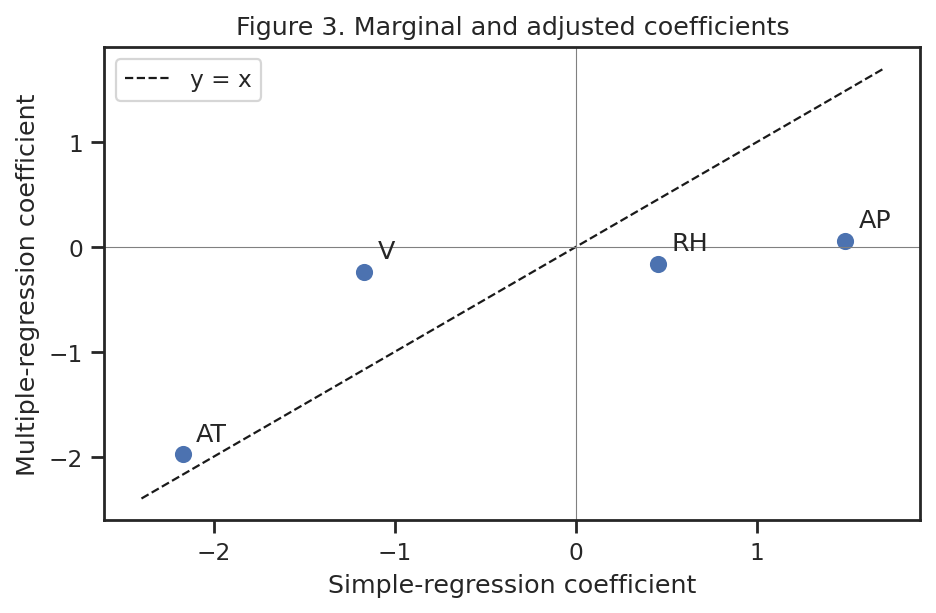

In [7]:
comparison = pd.DataFrame({
    "Simple": [simple[f].params[f] for f in FEATURES],
    "Multiple": multiple.params[FEATURES]
}, index=FEATURES)
print(comparison.round(5).to_string())
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(comparison.Simple, comparison.Multiple, s=45)
for feature, row in comparison.iterrows():
    ax.annotate(feature, (row.Simple, row.Multiple),
                xytext=(6, 6), textcoords="offset points")
ax.plot([-2.4, 1.7], [-2.4, 1.7], "k--", lw=1, label="y = x")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set(xlabel="Simple-regression coefficient",
       ylabel="Multiple-regression coefficient",
       title="Figure 3. Marginal and adjusted coefficients")
ax.legend()
fig.tight_layout()
plt.show()

## 1(f) - Nonlinear associations
I fitted $PE=\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon$ separately for each predictor. I compared each cubic model with its simple linear model using the joint null hypothesis $\beta_2=\beta_3=0$. The joint test checks nonlinear association even when one individual polynomial coefficient is insignificant. I fitted powers of $Z=X-\bar X$ for numerical stability; this spans exactly the same cubic model. The coefficient table uses these centered predictors.

               R2     p(Z^2)     p(Z^3)   Joint F    Joint p
Predictor                                                   
AT         0.9119  3.31e-231  3.65e-110  701.9673  3.48e-285
V          0.7750  8.98e-131     0.0137  393.3141  7.04e-165
AP         0.2975   2.19e-46   2.12e-67  195.8856   4.21e-84
RH         0.1537      0.101   1.44e-05   10.1889    3.8e-05

Cubic coefficients for Z = X - mean(X):
Variable  Intercept        Z         Z^2          Z^3
      AT    452.708 -2.42973   0.0325542   0.00267485
       V    451.214 -1.25026   0.0191768  0.000134357
      AP    453.082  1.96466   0.0442382  -0.00499116
      RH    454.443  0.53018 -0.00132506 -0.000152188


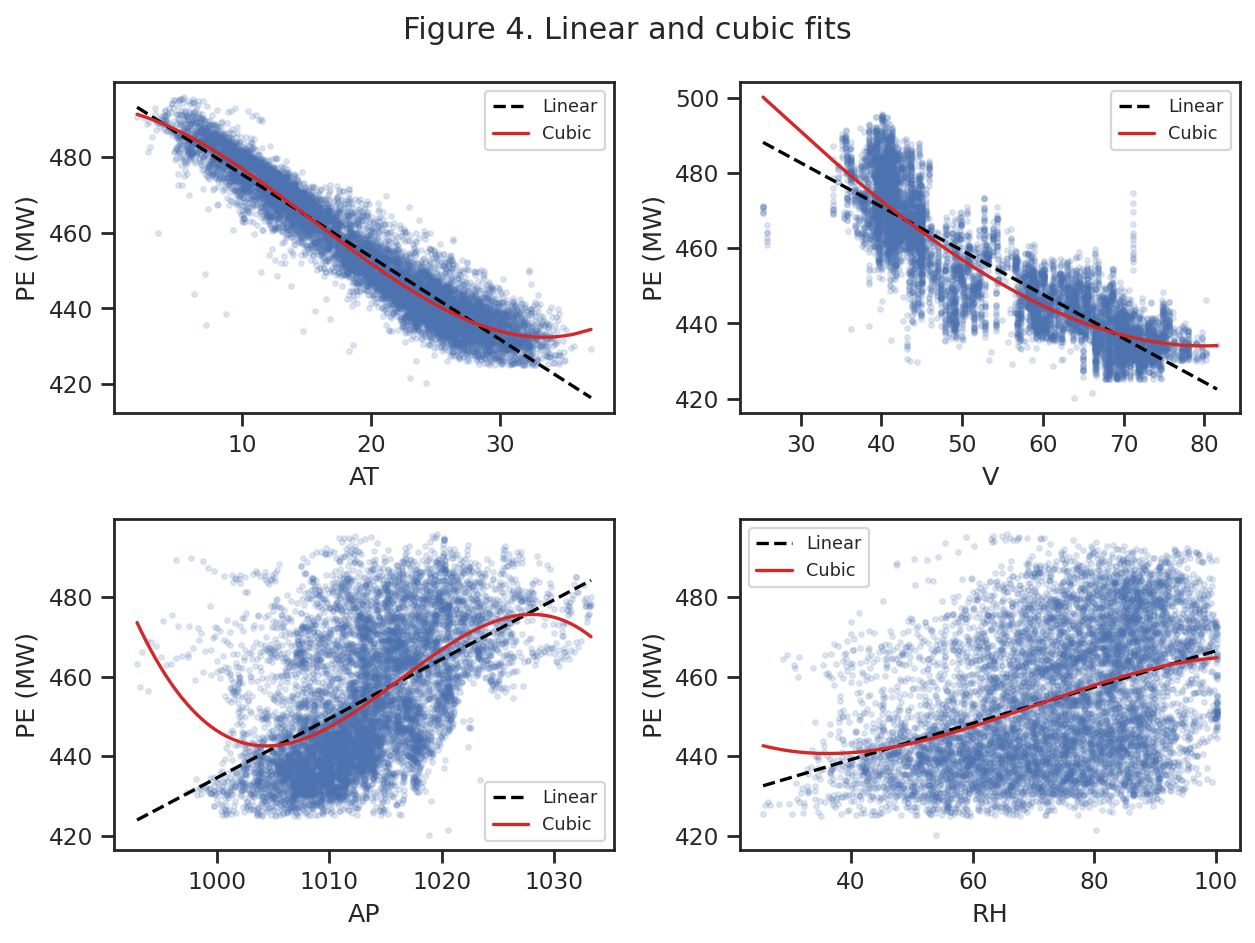

In [8]:
cubic = {}
nonlinear_rows = []
cubic_coefficients = []
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
for feature, ax in zip(FEATURES, axes.flat):
    x = X[feature]
    z = x - x.mean()
    design = pd.DataFrame({feature: z,
                           feature + "^2": z**2,
                           feature + "^3": z**3})
    model = sm.OLS(y, sm.add_constant(design)).fit()
    cubic[feature] = model
    fstat, pval, _ = model.compare_f_test(simple[feature])
    nonlinear_rows.append({
        "Predictor": feature, "R2": model.rsquared,
        "p(Z^2)": ptext(model.pvalues.iloc[2]),
        "p(Z^3)": ptext(model.pvalues.iloc[3]),
        "Joint F": fstat, "Joint p": ptext(pval)
    })
    cubic_coefficients.append([feature] + list(model.params))
    order = np.argsort(x.to_numpy())
    ax.scatter(x, y, s=5, alpha=0.15)
    ax.plot(x.iloc[order], simple[feature].fittedvalues.iloc[order],
            color="black", ls="--", label="Linear")
    ax.plot(x.iloc[order], model.fittedvalues.iloc[order],
            color="tab:red", label="Cubic")
    ax.set(xlabel=feature, ylabel="PE (MW)")
    ax.legend(fontsize=8)
fig.suptitle("Figure 4. Linear and cubic fits")
fig.tight_layout()
plt.show()
nonlinear_results = pd.DataFrame(nonlinear_rows).set_index("Predictor")
print(nonlinear_results.round(4).to_string())
print("\nCubic coefficients for Z = X - mean(X):")
print(pd.DataFrame(cubic_coefficients,
    columns=["Variable", "Intercept", "Z", "Z^2", "Z^3"]
).to_string(index=False, float_format=lambda v: f"{v:.6g}"))

All four joint-test p-values are below 0.05, so there is evidence of nonlinear association for AT, V, AP, and RH. The cubic fits have $R^2$ values of 0.9119, 0.7750, 0.2975, and 0.1537, respectively. RH shows the smallest improvement. Its centered quadratic coefficient is not significant ($p=0.101$), but its cubic term and the joint nonlinear test are significant. I retain the lower-order terms in each cubic model.

## 1(g) - Pairwise interactions
I fitted all four main effects and all six pairwise interactions. I centered each predictor at its full-data mean to make the main effects easier to interpret and reduce numerical scaling problems. Centering leaves the fitted values and interaction tests unchanged when all main effects are included.

In [9]:
def interaction_design(frame):
    result = frame.copy()
    for a, b in combinations(FEATURES, 2):
        result[a + ":" + b] = frame[a] * frame[b]
    return result

centered = X - X.mean()
interactions = interaction_design(centered)
interaction_model = sm.OLS(y, sm.add_constant(interactions)).fit()
print(coef_table(interaction_model).round(5).to_string())
print(f"R2 = {interaction_model.rsquared:.6f}")
significant_interactions = [
    name for name, p in interaction_model.pvalues.items()
    if ":" in name and p < ALPHA
]
print("Significant interactions:", ", ".join(significant_interactions))

       Coefficient  Std. error           t    p-value
const    452.69458     0.07453  6074.39265    <1e-300
AT        -1.80923     0.01610  -112.37310    <1e-300
V         -0.29859     0.00768   -38.87247    <1e-300
AP         0.13400     0.00993    13.49921   3.76e-41
RH        -0.11950     0.00418   -28.59961   1.1e-172
AT:V       0.02097     0.00090    23.33776  3.33e-117
AT:AP      0.00176     0.00234     0.75203      0.452
AT:RH     -0.00523     0.00081    -6.44436   1.22e-10
V:AP       0.00681     0.00133     5.13500   2.88e-07
V:RH       0.00084     0.00049     1.71600     0.0862
AP:RH     -0.00161     0.00076    -2.12508     0.0336
R2 = 0.936306
Significant interactions: AT:V, AT:RH, V:AP, AP:RH


The significant interaction terms are **AT:V, AT:RH, V:AP, and AP:RH**, with p-values of approximately $3.33\times10^{-117}$, $1.22\times10^{-10}$, $2.88\times10^{-7}$, and 0.0336. AT:AP ($p=0.452$) and V:RH ($p=0.0862$) are not significant at 0.05. The full interaction model has $R^2=0.9363$.

## 1(h) - Improving the regression model
I used 6,697 training observations and 2,871 test observations. The baseline includes all four predictors. The expanded model includes four main effects, four squared terms, and six pairwise interactions, plus an intercept.

I centered predictors using training means and applied the same transformation to the test set. Starting from the full quadratic model, I repeatedly removed the eligible term with the largest p-value above 0.05. A main effect is eligible for removal only if none of its squared or interaction terms remains. Thus every retained interaction keeps both parent main effects. All selection used training data only.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
baseline = sm.OLS(y_train, sm.add_constant(X_train)).fit()
train_means = X_train.mean()

def quadratic_design(frame):
    result = interaction_design(frame)
    for feature in FEATURES:
        result[feature + "^2"] = frame[feature]**2
    return sm.add_constant(result, has_constant="add")

Q_train = quadratic_design(X_train - train_means)
Q_test = quadratic_design(X_test - train_means)
terms = list(Q_train.columns)
removed = []
while True:
    quadratic = sm.OLS(y_train, Q_train[terms]).fit()
    eligible = []
    for term in terms:
        if term == "const":
            continue
        if term in FEATURES:
            children = [t for t in terms if t == term + "^2"
                        or (":" in t and term in t.split(":"))]
            if children:
                continue
        eligible.append(term)
    if not eligible:
        break
    worst = quadratic.pvalues[eligible].idxmax()
    if quadratic.pvalues[worst] <= ALPHA:
        break
    removed.append((worst, quadratic.pvalues[worst]))
    terms.remove(worst)

regression_scores = pd.DataFrame({
    "Model": ["Linear", "Selected quadratic"],
    "Train MSE": [
        mean_squared_error(y_train, baseline.fittedvalues),
        mean_squared_error(y_train, quadratic.fittedvalues)],
    "Test MSE": [
        mean_squared_error(y_test, baseline.predict(
            sm.add_constant(X_test))),
        mean_squared_error(y_test, quadratic.predict(Q_test[terms]))]
}).set_index("Model")
print("Train:", len(X_train), "Test:", len(X_test))
print("Removed terms (p-value at removal):")
for term, p in removed:
    print(f"  {term}: {p:.6f}")
print("\nFinal coefficients (centered predictors):")
print(coef_table(quadratic).round(5).to_string())
print("\nMSE (MW squared):")
print(regression_scores.round(5).to_string())

Train: 6697 Test: 2871
Removed terms (p-value at removal):
  V:RH: 0.867382
  V^2: 0.607733
  V:AP: 0.357826

Final coefficients (centered predictors):
       Coefficient  Std. error           t    p-value
const    453.22751     0.09891  4582.00619    <1e-300
AT        -1.81727     0.01948   -93.28022    <1e-300
V         -0.29853     0.00889   -33.59335  9.37e-229
AP         0.11693     0.01157    10.10682   7.64e-24
RH        -0.12510     0.00511   -24.47378  9.29e-127
AT:V       0.00825     0.00146     5.66317   1.55e-08
AT:AP      0.00698     0.00220     3.17450    0.00151
AT:RH     -0.00554     0.00096    -5.74153   9.79e-09
AP:RH     -0.00341     0.00094    -3.61938   0.000297
AT^2       0.01953     0.00241     8.11248   5.85e-16
AP^2      -0.00764     0.00133    -5.72595   1.07e-08
RH^2      -0.00194     0.00028    -7.04622   2.02e-12

MSE (MW squared):
                    Train MSE  Test MSE
Model                                  
Linear               20.58084  21.23986
Selecte

The eliminated terms, in order, are **V:RH, V$^2$, and V:AP**. The final model retains all four main effects, AT$^2$, AP$^2$, RH$^2$, and the interactions AT:V, AT:AP, AT:RH, and AP:RH. Every retained term has a p-value below 0.05.

The baseline has training MSE **20.58084** and test MSE **21.23986**. The selected quadratic model reduces these to **17.89084** and **18.66004**, respectively. Thus the additional terms improve test MSE by about **12.15%**. The interaction tests differ from part (g) because this model includes squared terms and is fitted on the training subset.

## 1(i) - KNN regression
I used Euclidean distance and uniform averaging for $k=1,\ldots,100$. For normalized features, I fitted a min-max scaler on the training set and applied it to both sets. Each training feature is mapped to [0, 1]. I selected the smallest test MSE, breaking ties in favor of the smaller $k$. Training MSE is computed by predicting the training observations themselves.

In [11]:
scaler = MinMaxScaler().fit(X_train)
feature_sets = {
    "Raw": (X_train.to_numpy(), X_test.to_numpy()),
    "Normalized": (scaler.transform(X_train), scaler.transform(X_test))
}
knn_curves = {}
knn_rows = []
for label, (train_x, test_x) in feature_sets.items():
    rows = []
    for k in range(1, 101):
        model = KNeighborsRegressor(
            n_neighbors=k, weights="uniform", metric="euclidean",
            algorithm="kd_tree", n_jobs=1
        ).fit(train_x, y_train)
        rows.append({
            "k": k,
            "Train MSE": mean_squared_error(
                y_train, model.predict(train_x)),
            "Test MSE": mean_squared_error(
                y_test, model.predict(test_x))
        })
    curve = pd.DataFrame(rows)
    knn_curves[label] = curve
    best = curve.loc[curve["Test MSE"].idxmin()]
    knn_rows.append({"Features": label, "k": int(best["k"]),
                     "Train MSE": best["Train MSE"],
                     "Test MSE": best["Test MSE"]})
knn_scores = pd.DataFrame(knn_rows).set_index("Features")
print(knn_scores.round(5).to_string())

            k  Train MSE  Test MSE
Features                          
Raw         5   10.60077  15.72682
Normalized  4    8.45435  14.29133


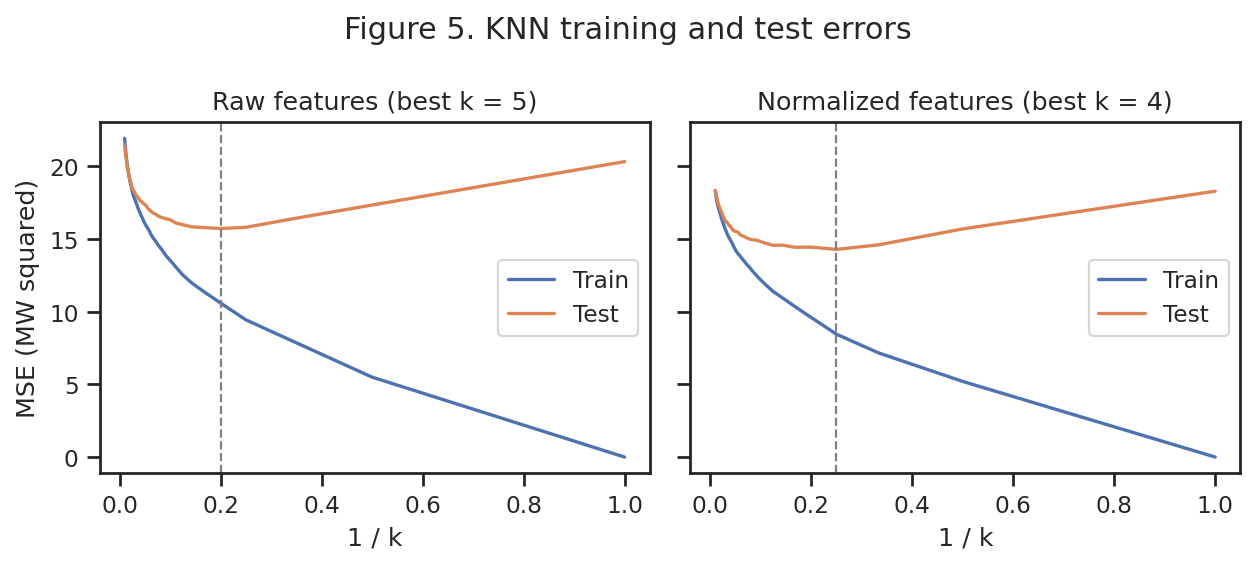

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), sharey=True)
for (label, curve), ax in zip(knn_curves.items(), axes):
    ordered = curve.sort_values("k", ascending=False)
    ax.plot(1 / ordered.k, ordered["Train MSE"], label="Train")
    ax.plot(1 / ordered.k, ordered["Test MSE"], label="Test")
    best_k = int(knn_scores.loc[label, "k"])
    ax.axvline(1 / best_k, color="gray", ls="--", lw=1)
    ax.set(xlabel="1 / k", title=f"{label} features (best k = {best_k})")
    ax.legend()
axes[0].set_ylabel("MSE (MW squared)")
fig.suptitle("Figure 5. KNN training and test errors")
fig.tight_layout()
plt.show()

For raw features, the best value is **$k=5$**, with training MSE **10.60077** and test MSE **15.72682**. For normalized features, the best value is **$k=4$**, with training MSE **8.45435** and test MSE **14.29133**. Normalization improves the minimum test MSE. The test curves increase at large $k$, where averaging over broader neighborhoods oversmooths the relationship.

## 1(j) - KNN and regression comparison

In [13]:
all_scores = pd.concat([
    regression_scores,
    knn_scores.rename(index={"Raw": "KNN raw",
                              "Normalized": "KNN normalized"})[
        ["Train MSE", "Test MSE"]]
])
print(all_scores.round(5).to_string())

                    Train MSE  Test MSE
Linear               20.58084  21.23986
Selected quadratic   17.89084  18.66004
KNN raw              10.60077  15.72682
KNN normalized        8.45435  14.29133


The selected quadratic regression has the smallest regression test MSE, **18.66004**. Both KNN models do better on this split: raw KNN reaches **15.72682**, and normalized KNN reaches **14.29133**. Normalized KNN reduces test MSE by about **23.41%** relative to the selected quadratic model.

KNN can adapt to local nonlinear relationships beyond a global quadratic fit. Scaling prevents the original measurement units from determining each feature's contribution to Euclidean distance. The quadratic model is more compact and provides interpretable coefficients, while KNN requires storing the training observations. Because I used test MSE to choose $k$, the reported minimum is a model-selection result, not an independent estimate of future prediction error.

## 2 - ISLR 2.4.1
### (a)
A flexible method should generally perform better. With many observations and few predictors, there is enough information to estimate a more complex relationship without a large increase in variance.

### (b)
A flexible method should generally perform worse. Many predictors and few observations make overfitting likely; a less flexible method can reduce variance.

### (c)
A flexible method should generally perform better because it can represent curvature that an inflexible model would miss, reducing bias.

### (d)
A flexible method should generally perform worse. When noise dominates, extra flexibility tends to fit random fluctuations and increase variance without recovering much additional signal.

## 3 - ISLR 2.4.7
### (a)
For the test point $(0,0,0)$, the Euclidean distance is
$d=\sqrt{X_1^2+X_2^2+X_3^2}$.

| Observation | Distance | Class |
|---|---|---|
| 1 | $3$ | Red |
| 2 | $2$ | Red |
| 3 | $\sqrt{10}\approx3.1623$ | Red |
| 4 | $\sqrt{5}\approx2.2361$ | Green |
| 5 | $\sqrt{2}\approx1.4142$ | Green |
| 6 | $\sqrt{3}\approx1.7321$ | Red |

The nearest-to-farthest order is 5, 6, 2, 4, 1, 3.

### (b)
For $K=1$, the prediction is **Green**, the class of observation 5.

### (c)
For $K=3$, the prediction is **Red**. Observations 5, 6, and 2 have classes Green, Red, and Red, giving Red two of the three votes.

### (d)
A **small $K$** is preferable for a highly nonlinear Bayes boundary because it gives a more flexible, local decision boundary. A large $K$ would smooth over local changes.

## References
1. UCI Machine Learning Repository, [Combined Cycle Power Plant](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant), including the dataset Readme.
2. James, Witten, Hastie, and Tibshirani, *An Introduction to Statistical Learning with Applications in R*, first edition, Chapter 2, Exercises 1 and 7. [Book website](https://www.statlearning.com/).
3. [statsmodels OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html).
4. scikit-learn: [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) and [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).